In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

# dot-bracket -> bpgrid (black and white)

# dot-bracket and sequence -> colored bpgrid (based on AU or GC bp)

In [5]:
df_subset_numpeaks1or2 = pd.read_parquet('dataset_with_fpts_subset_numpeaks1or2.parquet')
df = df_subset_numpeaks1or2

In [7]:
def has_other_letters(s):
    valid_chars = set('AUCG')
    return any(char not in valid_chars for char in s)

counter = 0
for row in df.itertuples():
    if has_other_letters(row.sequence):
        #print(row.Index, row.sequence)
        counter += 1
print(counter)

640


In [12]:
mask_rows = df['sequence'].apply(lambda seq: not has_other_letters(seq))
df_subset = df[mask_rows]
print(len(df_subset))

7581


In [13]:
df_subset_numpeaks1or2 = df_subset

In [14]:
row_stride = 500
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index, row.mfe_structure)

0 ...............
500 ....................
1000 (.((((......)))).)....
1500 ........................
2000 ((((((............))))))..
2500 .........((((.((....)).)))).
3000 ...........((.((((....)))).)).
3500 ..(((((....((......))...)))))...
4000 ((((((((((((((((((...(((....))))))))).))....))))))))))..
4500 ....((((((.....((((......))))...)))))).........................
5000 (((((((((((..........(((((((((............)))).)))))))))..))))))).
5500 .(((((((((((......))))........))))))).((((...((((......))))...))))...
6000 .(((((...(((((.....))))).((((......((.(((((...))))).))....))))...))))).
6500 (((((((.((.(...(((((((((((.....)).)))))))))..((((.(.....).))))).))))))))).
7000 .((.((((.(((((((((((...)))).))).)))).))))..)).(.(((..((((((....)))).))..))).).
7500 ((((((...(((.....(((((((((......(((((((((....))).))))))(((....)))))))))))))))...))))))
8000 ((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....


In [23]:
def get_bp_value(nuc1, nuc2):
    if (nuc1 == 'A' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'A'):
        return 1
    if (nuc1 == 'G' and nuc2 == 'C') or (nuc1 == 'C' and nuc2 == 'G'):
        return 2
    if (nuc1 == 'G' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'G'):
        return 3
    else:
        raise ValueError(f"Nucleotides {nuc1} and {nuc2} do not form a valid base pair")

def dotbrack_seq_to_colored_matrix(dot_bracket_string, seq_string):    
    n = len(dot_bracket_string)
    if len(seq_string) != n:
        raise ValueError("dot_bracket_string and seq_string must be the same length")
    # 1. Initialize an N x N matrix with zeros
    matrix = [[0 for _ in range(n)] for _ in range(n)]
    stack = []
    nuc_stack = []
    
    # 2. Loop through the string
    for i, char in enumerate(dot_bracket_string):
        nuc = seq_string[i] # nucleotide
        if char == '(':
            stack.append(i) # Save the index of the open bracket
            nuc_stack.append(nuc) # save the first nucleotide of the base pair
        elif char == ')':
            if stack:
                j = stack.pop() # Retrieve the matching open bracket index
                nuc1 = nuc_stack.pop() # retrieve the first nucleotide of the base pair
                
                bp_value = get_bp_value(nuc1, nuc)

                # 3. Mark the base pair (convert from 0-based to 1-based index if desired)
                matrix[i][j] = bp_value
                matrix[j][i] = bp_value
                
    return matrix

..(((((....((......))...)))))...
UCCGGGCCAAUUCCAAGCAGACCUGCCUGAAA
32


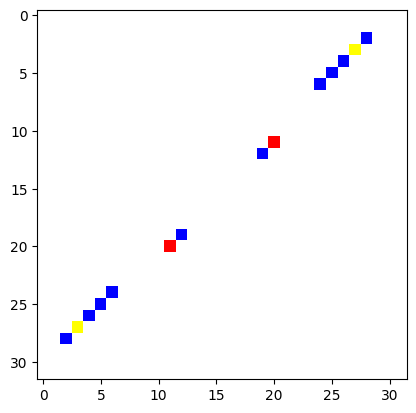

In [27]:
dotbracket = df_subset_numpeaks1or2.loc[3500, 'mfe_structure']
seq = df_subset_numpeaks1or2.loc[3500, 'sequence']
print(dotbracket)
print(seq)
print(len(dotbracket))
bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)
plt.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)

((((((((.(((((((.((((...........(((((((...(((...)))...))))))).........)))).))))..))).))))))))....
AGCUGGUCCAAUGGUAAUGGGUUAUCAGAACUUAUUAACACCAGUGUCACUAAAGUUGAUGUACAGUCCCCCCACUGCUAAAUUUGACUGGCUUAAA
97


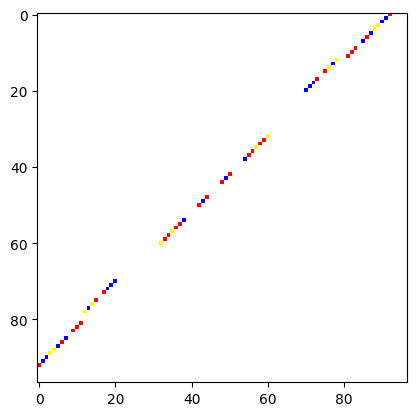

In [28]:
dotbracket = df_subset_numpeaks1or2.loc[8000, 'mfe_structure']
seq = df_subset_numpeaks1or2.loc[8000, 'sequence']
print(dotbracket)
print(seq)
print(len(dotbracket))
bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)
plt.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)

379


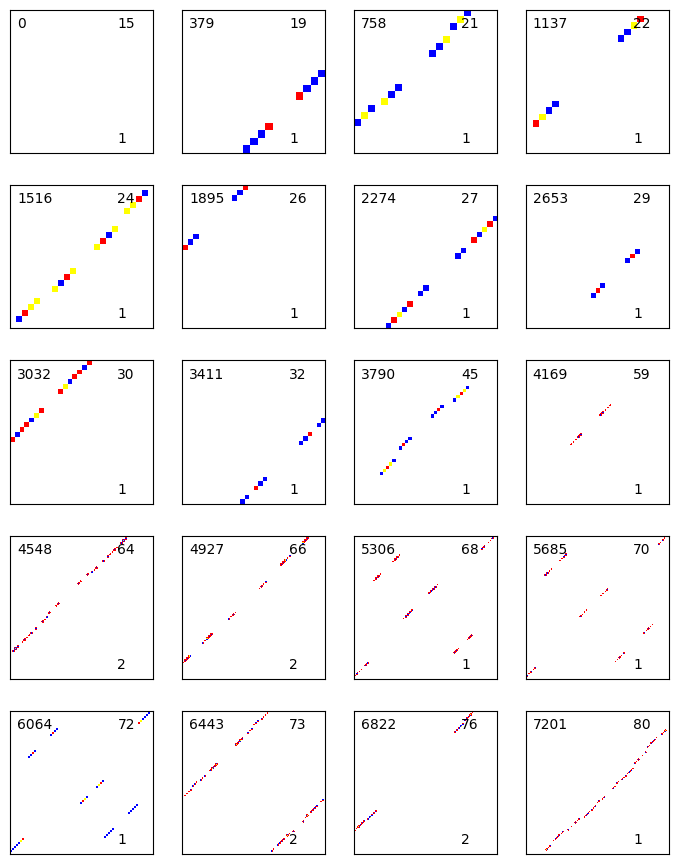

In [30]:
width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

row_stride = int(len(df_subset_numpeaks1or2)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset_numpeaks1or2.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored.pdf', bbox_inches='tight', pad_inches=0.25)

277


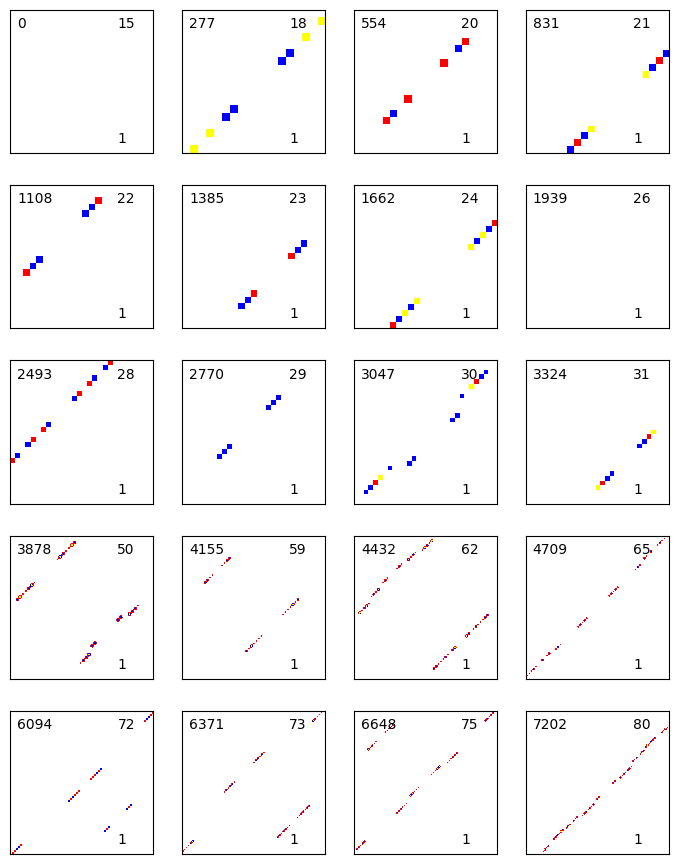

In [31]:
# 1 peak

width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==1]
row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored_1peak.pdf', bbox_inches='tight', pad_inches=0.25)

101


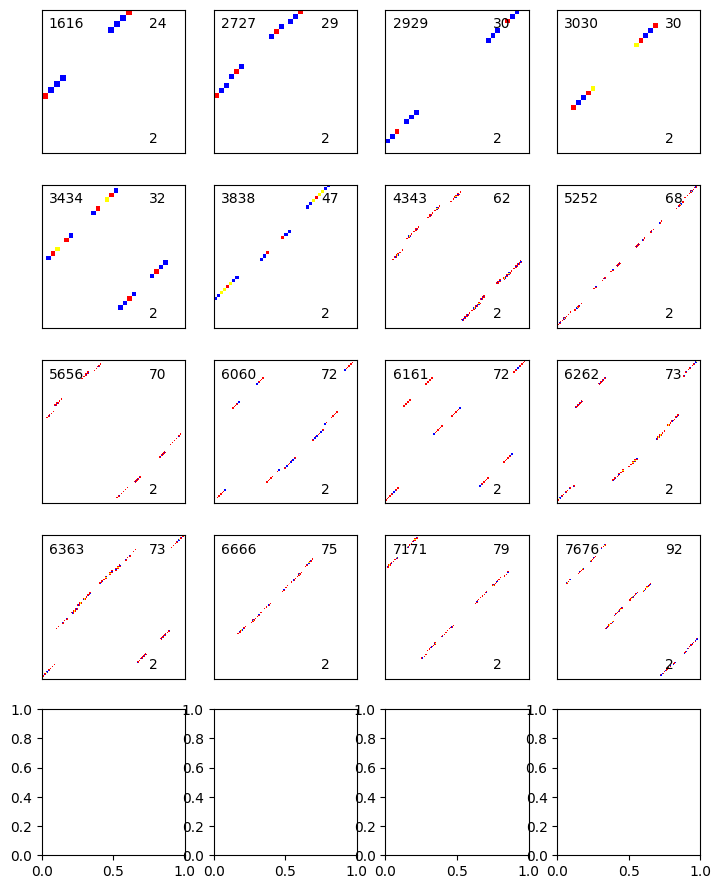

In [32]:
# 2 peaks

width_inch = 8.5
height_inch = 11
n_x = 4
n_y = 5
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)

df_here = df_subset_numpeaks1or2[df_subset_numpeaks1or2['num_peaks']==2]
row_stride = int(len(df_here)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_here.itertuples():
    if row.Index % row_stride == 0:
        dotbracket = row.mfe_structure
        seq = row.sequence
        bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.05, str(row.num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('bpgrid_colored_2peaks.pdf', bbox_inches='tight', pad_inches=0.25)